In [2]:
# ---- cell 1: imports + plot style ----
%matplotlib widget
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rc('font', family='serif')
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('axes', titlesize=16, labelsize=16)
plt.rc('legend', fontsize=14)
plt.rc('figure', titlesize=18)

mid = lambda lo, hi: (np.asarray(hi) + np.asarray(lo)) / 2
half = lambda lo, hi: (np.asarray(hi) - np.asarray(lo)) / 2

In [3]:
# ---- cell 2: up/down launch comparison (hot Cs test). ADD ROWS HERE ----
# cts_up, cts_dn in units of 1e3. pmt_excess = PMT rate (gate open - closed), kHz.
updown = pd.DataFrame([
    dict(date='2026-07-21', ig=8.0e-9, track=175, delay_up=0,   delay_dn=667, toa_up=65, toa_dn=738, cts_up=27,     cts_dn=3.6, pmt_excess=250),
    dict(date='2026-07-21', ig=7.8e-9, track=160, delay_up=1.7, delay_dn=590, toa_up=73, toa_dn=663, cts_up=31,     cts_dn=5.3, pmt_excess=250),
    dict(date='2026-07-21', ig=7.8e-9, track=140, delay_up=16,  delay_dn=484, toa_up=88, toa_dn=555, cts_up=34,     cts_dn=10,  pmt_excess=250),
    dict(date='2026-07-23', ig=7.1e-9, track=175, delay_up=0,   delay_dn=667, toa_up=65, toa_dn=738, cts_up=np.nan, cts_dn=np.nan, pmt_excess=215),
    dict(date='2026-07-23', ig=7.1e-9, track=160, delay_up=1.7, delay_dn=590, toa_up=73, toa_dn=663, cts_up=20,     cts_dn=3.1, pmt_excess=215),
    dict(date='2026-07-23', ig=7.1e-9, track=140, delay_up=16,  delay_dn=484, toa_up=88, toa_dn=555, cts_up=26,     cts_dn=5.7, pmt_excess=215),
    dict(date='2026-07-24', ig=6.3e-9, track=140, delay_up=16,  delay_dn=484, toa_up=88, toa_dn=555, cts_up=8,      cts_dn=1.5, pmt_excess=7),
    dict(date='2026-08-03', ig=5.5e-9, track=140, delay_up=16,  delay_dn=484, toa_up=88, toa_dn=555, cts_up=16,     cts_dn=3.4, pmt_excess=125),
])
updown['date'] = pd.to_datetime(updown['date'])
updown['ratio'] = updown['cts_dn'] / updown['cts_up']
updown

,date,ig,track,delay_up,delay_dn,toa_up,toa_dn,cts_up,cts_dn,pmt_excess,ratio
0,2026-07-21,8.000000e-09,175,0.0,667,65,738,27.0,3.6,250,0.133333
1,2026-07-21,7.800000e-09,160,1.7,590,73,663,31.0,5.3,250,0.170968
2,2026-07-21,7.800000e-09,140,16.0,484,88,555,34.0,10.0,250,0.294118
3,2026-07-23,7.100000e-09,175,0.0,667,65,738,NaN,NaN,215,NaN
4,2026-07-23,7.100000e-09,160,1.7,590,73,663,20.0,3.1,215,0.155000
5,2026-07-23,7.100000e-09,140,16.0,484,88,555,26.0,5.7,215,0.219231
6,2026-07-24,6.300000e-09,140,16.0,484,88,555,8.0,1.5,7,0.187500
7,2026-08-03,5.500000e-09,140,16.0,484,88,555,16.0,3.4,125,0.212500


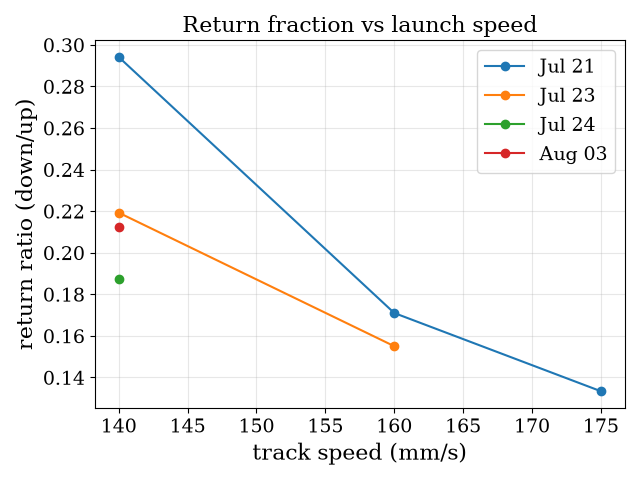

In [4]:
# ---- cell 3: return ratio vs track speed, one curve per day ----
for d, g in updown.groupby('date'):
    g = g.sort_values('track')
    plt.plot(g['track'], g['ratio'], 'o-', label=d.strftime('%b %d'))
plt.xlabel('track speed (mm/s)')
plt.ylabel('return ratio (down/up)')
plt.title('Return fraction vs launch speed')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

In [5]:
# ---- cell 4: up and down counts vs track speed ----
for d, g in updown.groupby('date'):
    g = g.sort_values('track')
    l, = plt.plot(g['track'], g['cts_up'], 'o-', label=d.strftime('%b %d') + ' up')
    plt.plot(g['track'], g['cts_dn'], 's--', color=l.get_color(), label=d.strftime('%b %d') + ' down')
plt.yscale('log')
plt.xlabel('track speed (mm/s)')
plt.ylabel('integrated counts / 1e3')
plt.legend(fontsize=10, ncol=2)
plt.grid(alpha=0.3, which='both')
plt.tight_layout()

In [6]:
# ---- cell 5: ratio vs Cs background proxy, at fixed track speed ----
track_sel = 140

g = updown[updown['track'] == track_sel]
plt.plot(g['pmt_excess'], g['ratio'], 'o')
for _, r in g.iterrows():
    plt.annotate(r['date'].strftime('%b %d'), (r['pmt_excess'], r['ratio']),
                 textcoords='offset points', xytext=(6, 4), fontsize=11)
plt.xlabel('PMT rate, gate open - closed (kHz)')
plt.ylabel('return ratio (down/up)')
plt.title('track = %d mm/s' % track_sel)
plt.grid(alpha=0.3)
plt.tight_layout()

In [7]:
# ---- cell 6: MOT fill data. ADD ROWS HERE ----
# N in atoms, fill in seconds, ranges as _lo/_hi (put same value twice if single number)
mot = pd.DataFrame([
    dict(date='2026-07-27', gate='open',   ig=7.0e-9,  fill_lo=4.0,  fill_hi=4.0,  N_lo=3.0e7,  N_hi=3.0e7,  note='pressure gauge acting weird'),
    dict(date='2026-07-30', gate='closed', ig=5.9e-9,  fill_lo=6.0,  fill_hi=7.0,  N_lo=1.7e7,  N_hi=1.7e7,  note=''),
    dict(date='2026-07-30', gate='open',   ig=4.3e-9,  fill_lo=8.8,  fill_hi=11.7, N_lo=2.6e7,  N_hi=2.9e7,  note=''),
    dict(date='2026-07-30', gate='closed', ig=1.4e-8,  fill_lo=2.4,  fill_hi=2.4,  N_lo=7.4e6,  N_hi=7.4e6,  note='RGA on 30 min'),
    dict(date='2026-07-30', gate='open',   ig=7.0e-9,  fill_lo=6.0,  fill_hi=6.0,  N_lo=1.9e7,  N_hi=1.9e7,  note='RGA on 3 hr'),
    dict(date='2026-07-30', gate='open',   ig=5.7e-9,  fill_lo=7.0,  fill_hi=7.0,  N_lo=2.3e7,  N_hi=2.3e7,  note='RGA off few min'),
    dict(date='2026-07-31', gate='closed', ig=5.6e-9,  fill_lo=3.7,  fill_hi=3.7,  N_lo=6.0e7,  N_hi=6.0e7,  note=''),
    dict(date='2026-07-31', gate='open',   ig=4.0e-9,  fill_lo=4.0,  fill_hi=4.0,  N_lo=7.0e7,  N_hi=7.0e7,  note=''),
    dict(date='2026-08-03', gate='closed', ig=6.8e-9,  fill_lo=2.6,  fill_hi=2.8,  N_lo=9.7e7,  N_hi=10.2e7, note=''),
    dict(date='2026-08-03', gate='open',   ig=5.3e-9,  fill_lo=2.8,  fill_hi=2.9,  N_lo=11.1e7, N_hi=11.5e7, note=''),
])
mot['date'] = pd.to_datetime(mot['date'])
mot['N'] = mid(mot['N_lo'], mot['N_hi'])
mot['fill'] = mid(mot['fill_lo'], mot['fill_hi'])
mot['rate'] = mot['N'] / mot['fill']       # steady-state loading rate proxy
mot

,date,gate,ig,fill_lo,fill_hi,N_lo,N_hi,note,N,fill,rate
0,2026-07-27,open,7.000000e-09,4.0,4.0,30000000.0,30000000.0,pressure gauge acting weird,30000000.0,4.00,7.500000e+06
1,2026-07-30,closed,5.900000e-09,6.0,7.0,17000000.0,17000000.0,,17000000.0,6.50,2.615385e+06
2,2026-07-30,open,4.300000e-09,8.8,11.7,26000000.0,29000000.0,,27500000.0,10.25,2.682927e+06
3,2026-07-30,closed,1.400000e-08,2.4,2.4,7400000.0,7400000.0,RGA on 30 min,7400000.0,2.40,3.083333e+06
4,2026-07-30,open,7.000000e-09,6.0,6.0,19000000.0,19000000.0,RGA on 3 hr,19000000.0,6.00,3.166667e+06
5,2026-07-30,open,5.700000e-09,7.0,7.0,23000000.0,23000000.0,RGA off few min,23000000.0,7.00,3.285714e+06
6,2026-07-31,closed,5.600000e-09,3.7,3.7,60000000.0,60000000.0,,60000000.0,3.70,1.621622e+07
7,2026-07-31,open,4.000000e-09,4.0,4.0,70000000.0,70000000.0,,70000000.0,4.00,1.750000e+07
8,2026-08-03,closed,6.800000e-09,2.6,2.8,97000000.0,102000000.0,,99500000.0,2.70,3.685185e+07
9,2026-08-03,open,5.300000e-09,2.8,2.9,111000000.0,115000000.0,,113000000.0,2.85,3.964912e+07


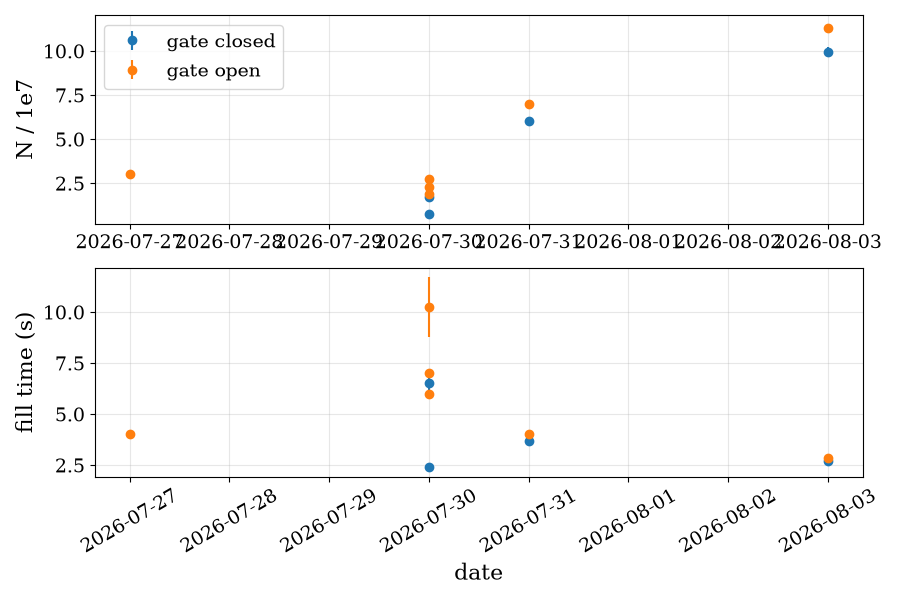

In [8]:
# ---- cell 7: MOT atom number and fill time vs date ----
plt.figure(figsize=(9, 6))

plt.subplot(2, 1, 1)
for gate, g in mot.groupby('gate'):
    plt.errorbar(g['date'], g['N'] / 1e7, yerr=half(g['N_lo'], g['N_hi']) / 1e7,
                 fmt='o', label='gate ' + gate)
plt.ylabel('N / 1e7')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2, 1, 2)
for gate, g in mot.groupby('gate'):
    plt.errorbar(g['date'], g['fill'], yerr=half(g['fill_lo'], g['fill_hi']),
                 fmt='o', label='gate ' + gate)
plt.ylabel('fill time (s)')
plt.xlabel('date')
plt.grid(alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()